In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

## Загрузка данных

#### Для лабораторной был взят датасет PJME_hourly, который показывает количество затрат электроэнергии каждый час в течении дня

In [ ]:
FILE_PATH = 'PJME_hourly.csv'  
SEQ_LENGTH = 24                # Длина окна (24 часа истории для прогноза)
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

print(f"Загрузка данных из {FILE_PATH}...")

# Читаем CSV сразу с парсингом дат и установкой индекса
df = pd.read_csv(FILE_PATH, parse_dates=['Datetime'], index_col='Datetime')
df = df.sort_index() # Важно отсортировать по времени!

print("Первые 24 строки:")
display(df.head(24))

data = df['PJME_MW'].values.astype(float)

Загрузка данных из PJME_hourly.csv...
Первые 24 строки:


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0
2002-01-01 06:00:00,28654.0
2002-01-01 07:00:00,29308.0
2002-01-01 08:00:00,29595.0
2002-01-01 09:00:00,29943.0


## Подготовка данных

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data.reshape(-1, 1))
data_tensor = torch.FloatTensor(data_normalized).view(-1)

def create_sequences(data, seq_length):

    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.stack(ys)

X, y = create_sequences(data_tensor, SEQ_LENGTH)

train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Решейп для LSTM: (Batch, Sequence, Features) -> (N, 24, 1)
X_train = X_train.unsqueeze(-1)
X_test = X_test.unsqueeze(-1)

# Создаем DataLoader (вот это и есть "превращение в dataset")
train_dataset = TensorDataset(X_train, y_train.unsqueeze(-1))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

Формирование последовательностей...


## Модель

In [39]:
class ElectricityLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super(ElectricityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытых состояний
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Прямой проход
        out, _ = self.lstm(x, (h0, c0))
        
        # Берем выход последнего шага времени: out[:, -1, :]
        out = self.fc(out[:, -1, :])
        return out

model = ElectricityLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

## Обучение

Epoch 5/10 | Train Loss: 0.000117 | Test Loss: 0.000138
Epoch 10/10 | Train Loss: 0.000077 | Test Loss: 0.000104


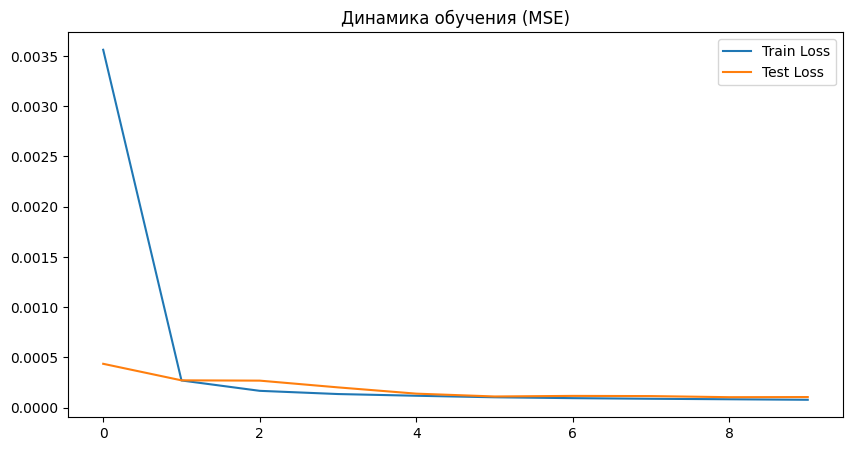

In [ ]:
train_hist = []
test_hist = []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    # Валидация на всей тестовой выборке
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)
        test_loss = criterion(test_pred, y_test.unsqueeze(-1))
    
    train_loss = np.mean(batch_losses)
    train_hist.append(train_loss)
    test_hist.append(test_loss.item())
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss.item():6f}")

# График потерь
plt.figure(figsize=(10, 5))
plt.plot(train_hist, label='Train Loss')
plt.plot(test_hist, label='Test Loss')
plt.title('Динамика обучения (MSE)')
plt.legend()
plt.show()

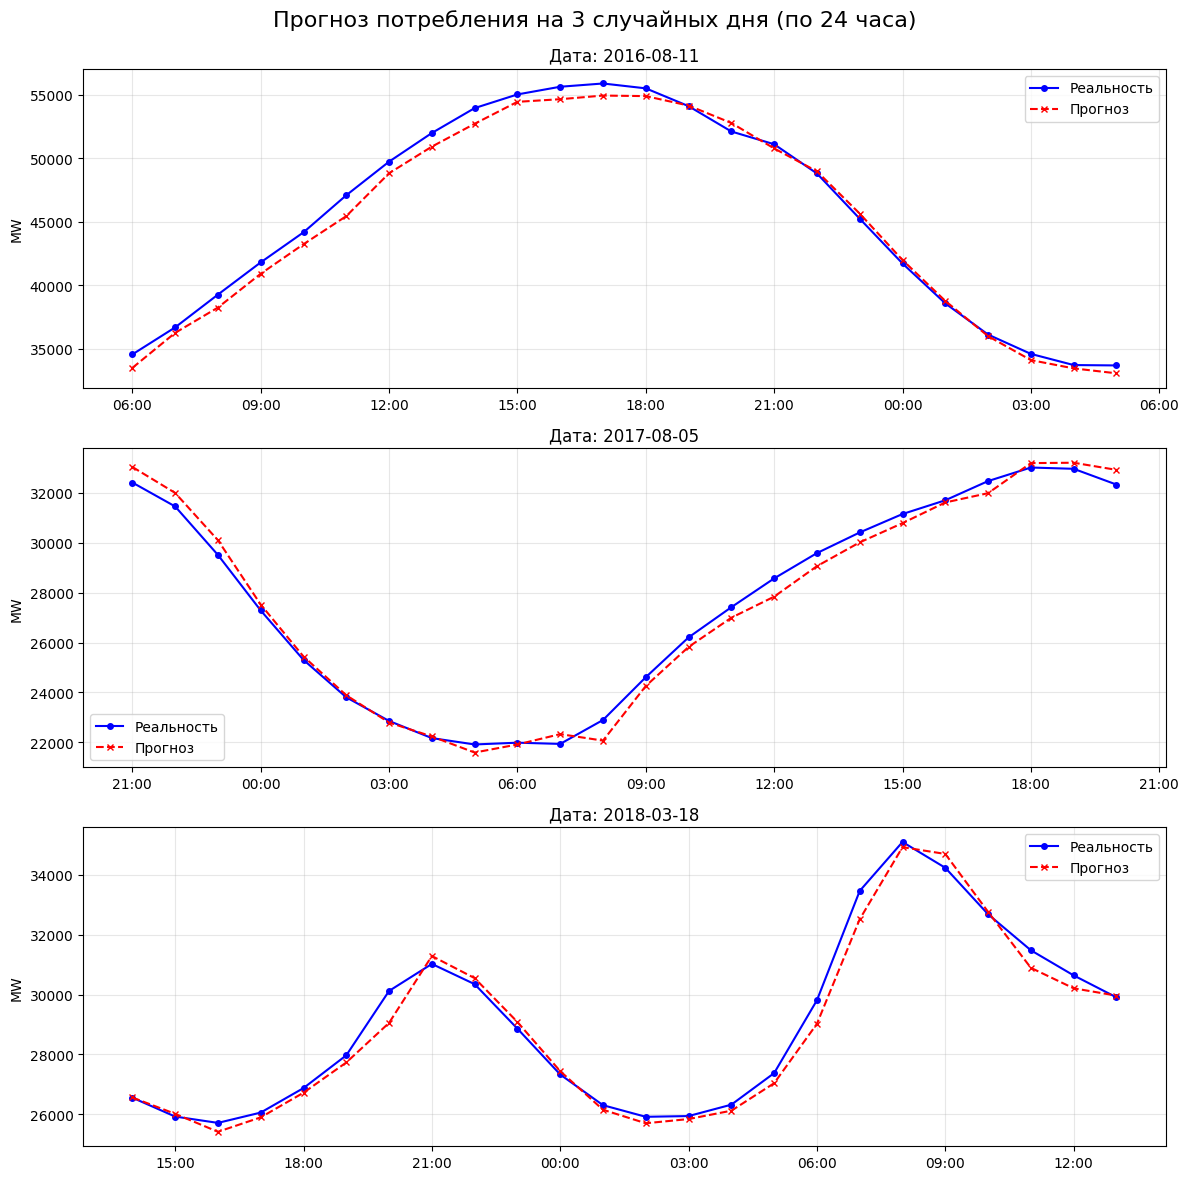

In [43]:
model.eval()
with torch.no_grad():
    preds = model(X_test)
    preds_real = scaler.inverse_transform(preds.numpy())
    y_test_real = scaler.inverse_transform(y_test.unsqueeze(-1).numpy())

# Подготовка дат для теста
test_dates = df.index[train_size + SEQ_LENGTH:]

# Выбираем 3 случайных дня для отображения
# Нам нужно выбрать случайные индексы, но с отступом, чтобы взять 24 часа подряд
random_indices = np.random.choice(len(test_dates) - 24, 3, replace=False)

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle(f'Прогноз потребления на 3 случайных дня (по {SEQ_LENGTH} часа)', fontsize=16)

for i, idx in enumerate(random_indices):
    # Берем срез 24 часа, начиная со случайного индекса
    # Это покажет, как модель предсказывала час за часом в течение суток
    day_dates = test_dates[idx : idx+24]
    day_real = y_test_real[idx : idx+24]
    day_pred = preds_real[idx : idx+24]
    
    # Дата для заголовка (берем дату первого часа)
    date_str = pd.to_datetime(day_dates[0]).strftime('%Y-%m-%d')
    
    ax = axes[i]
    ax.plot(day_dates, day_real, label='Реальность', color='blue', marker='o', markersize=4)
    ax.plot(day_dates, day_pred, label='Прогноз', color='red', linestyle='--', marker='x', markersize=4)
    
    ax.set_title(f'Дата: {date_str}')
    ax.set_ylabel('MW')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Форматирование оси X для каждого подграфика
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.subplots_adjust(top=0.93) # Немного места для общего заголовка
plt.show()